In [1]:
# standard libraries
import joblib, warnings, time
import pandas as pd
import numpy as np
import os
import random
warnings.filterwarnings('ignore')

# visualizations
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             ConfusionMatrixDisplay, precision_recall_fscore_support, f1_score,
                             roc_auc_score)


# tf keras
import tensorflow as tf
from tensorflow import keras
from keras import metrics

# individual classifiers
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree


# ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# others

2026-04-17 12:36:23.703340: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-17 12:36:23.711804: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 12:36:24.175824: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 12:36:25.496235: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
TARGET_NAMES = ['Low Bleaching', 'Medium Bleaching', 'High Bleaching']
RANDOM_STATE = 42

data = joblib.load('artifacts/data_splits.pkl')

X_train          = data['X_train']
X_val            = data['X_val']
X_test           = data['X_test']
y_train          = data['y_train']
y_val            = data['y_val']
y_test           = data['y_test']
feature_cols     = data['feature_cols']
numeric_features = data['numeric_features']
categorical_features = data['categorical_features']
feature_groups   = data['feature_groups']

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (20680, 35) | Val: (6894, 35) | Test: (6894, 35)


In [3]:
# df_train is the concatenated dataset with 35 features and target as bleaching_class

df_train = pd.concat([pd.DataFrame(y_train), pd.DataFrame(X_train)], axis=1)

#### Feature EDA for Logistic Regression

Based on the correlation matrices in the notebook 01_BCO_preprocessing_eda.ipynb, we will conduct feature selection, since Logistic regression performs best on non multicolinear features. Then we will do further feature reduction based on VIF score.

In [4]:
keep_features = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw'],
'ssta_family': ['ssta_standard_deviation','ssta_frequency'],
'tsa_family': ['tsa_frequency'],
'environmental': ['turbidity', 'cyclone_frequency'],
'temporal': ['year'],
'categorical': ['exposure', 'substrate_name']}

In [5]:
# Flatten the keep_features dictionary into a single list
keep_features_flat = [f for group in keep_features.values() for f in group]

# separate train dataframe for Logistic regession model
df_train_lr = df_train[keep_features_flat]
print(df_train_lr.shape)
df_train_lr.head()
# df_train_lr.dtypes()

(20680, 16)


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m,climsst,ssta,tsa,ssta_dhw,ssta_standard_deviation,ssta_frequency,tsa_frequency,turbidity,cyclone_frequency,year,exposure,substrate_name
16267,4.5981,118.8619,32.43,5.0,302.09,0.57,0.01,2.06,0.80,10.0,3.0,0.0727,54.54,2018,Sheltered,Hard Coral
8574,22.5506,114.3092,71.82,3.0,300.24,-0.22,-0.49,0.00,1.64,3.0,0.0,0.4006,55.21,2005,Sheltered,Nutrient Indicator Algae
34631,24.5001,-81.6296,8411.00,5.1,299.79,3.91,3.91,51.11,2.58,25.0,25.0,0.1203,58.42,2015,Exposed,unknown
613,24.8360,-80.7280,1490.84,3.2,300.55,0.58,-0.52,4.91,1.00,4.0,2.0,0.1836,60.12,2005,Sometimes,unknown
14685,4.5211,118.8048,4225.93,7.0,301.80,-0.34,-0.53,0.00,0.81,8.0,0.0,0.1644,54.53,2017,Sheltered,Hard Coral


In [6]:
# Compute VIF on the reduced feature set
# VIF runs on numeric data and does not consider Nan's
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF
numeric_cols_for_vif = df_train_lr.select_dtypes(include=['int32', 'float64']).columns
df_vif = df_train_lr[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

vif_data

,feature,VIF
0,latitude_degrees,2.194734
1,longitude_degrees,1.472224
2,distance_to_shore,1.123017
3,depth_m,4.132111
4,climsst,414.166715
5,ssta,1.735320
6,tsa,1.992316
7,ssta_dhw,2.733788
8,ssta_standard_deviation,33.503360
9,ssta_frequency,4.602572


Most VIF values are between 1 and 5. 3 features stand out: climsst 414, cyclone_frequency 60, ssta_std_deviation 33 and year 491. climsst is the long‑term climatological SST, and it is strongly tied to lat/long, ssta(anomaly = sst - climsst), tsa, ssta_dhw (derived from anomalies). So it’s mathematically redundant and we can drop it.

cyclone_frequency is surprising and hard to explain. It's probably correlating with a spatial or geographic variable. Cyclone frequency is strongly tied to year and location in many datasets. If cyclone events cluster in certain years or regions, VIF will explode. - Drop

ssta_std_deviation is correlated with SST variability metrics - Drop

In [7]:
# Drop climsst and rerun VIF
numeric_cols_for_vif = df_train_lr.select_dtypes(include=['int32', 'float64']).columns
numeric_cols_for_vif = numeric_cols_for_vif.drop(['climsst', 'cyclone_frequency', 'ssta_standard_deviation'])
df_vif = df_train_lr[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data

,feature,VIF
0,latitude_degrees,1.756701
1,longitude_degrees,1.420644
2,distance_to_shore,1.104627
3,depth_m,4.115813
4,ssta,1.724095
5,tsa,1.967552
6,ssta_dhw,2.602919
7,ssta_frequency,4.534949
8,tsa_frequency,2.518064
9,turbidity,2.900042


All spatial + thermal + frequency features look great! everything is below 10. Year has the highest VIF, because thermal anomalies trend over time and bleaching events cluster in certain years - worth keeping an eye on. Keep year for baseline as random forest/ boosting can handle the temporal structure later.

We are down to 11 numeric + 2categorical features. No need to run PCA for dimensionality reduction as VIF is clean, so there is no colinearity to fix.

Feature scaling for baseline to be done at the time of running model experiments.

#### Workflow:
Shared Functions - to be used by all the models:
1. build preprocessor
2. evaluate models
3. plot confusion matrices
4. Run experiments for each model
5. Store all results for ablation study
6. choose best model - based on ablation study metrics
7. final evaluate on test set

#### Model Build + Train
Build, preprocess, and train classifiers for coral bleaching severity prediction.

The function constructs a sklearn Pipeline that handles all preprocessing steps inline, ensuring no data leakage between train and validation sets. Preprocessing and model fitting use the globally defined X_train / y_train splits.

Preprocessing steps:

SimpleImputer(strategy='median'): Imputes missing values with the column median. Median is preferred over mean for skewed environmental measurements (e.g. depth_m, ssta_dhw) as it is robust to outliers.
StandardScaler: Zero-mean, unit-variance scaling. Required for Logistic Regression, which is sensitive to feature magnitude differences. Without scaling, features with larger ranges (e.g. ssta_dhw vs turbidity) would dominate the coefficient estimates.
Categorical features (2: exposure, substrate_name):

OneHotEncoder(drop='first', handle_unknown='ignore'): Converts nominal categories to binary dummy variables. drop='first' removes one category per feature to avoid the multicollinearity. handle_unknown='ignore' prevents errors if unseen categories appear in the validation or test set.
We use max_iter=1000 to ensure convergence, class_weight='balanced' to address the class imbalance as it would penalize the majority class with lower weights. Default regularisation strength (L2). C is the inverse of regularisation, 1.0 is a neutral starting point for the baseline, to be tuned in experiments.

#### Model Evaluate
We evaluate the models on the validation set and report per-class and overall performance metrics.

Metrics reported :

Per-class accuracy : diagonal of confusion matrix / row sum. Reported separately because overall accuracy is misleading given the class imbalance.

Overall accuracy : fraction of all predictions that are correct. Included for reference, its not the primary evaluation metric.

Classification Report : per-class Precision, Recall, F1-score, and support. Macro F1 (unweighted average across classes) is the primary metric for comparing models, as it weights all classes equally regardless of support size.

Confusion Matrix : Off-diagonal cells show misclassification patterns.

TP / FP / FN / TN per class : derived from the confusion matrix for manual inspection of error types.

In [8]:
# Store All results for Ablation Study
ALL_RESULTS = {}

In [9]:
def build_pipeline(clf, numeric_strategy='median', num_features=None, cat_features=None):
    """
    Build a pipeline for ANY sklearn classifier.
    """
    # fall back to globals if not specified
    num_cols = num_features if num_features is not None else numeric_features
    cat_cols = cat_features if cat_features is not None else categorical_features

    # Numeric preprocessing: 
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=numeric_strategy)),
        ('scaler',  StandardScaler())
    ])

    # Categorical preprocessing: one-hot encode
    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    # Combine into a ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer,     num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

    # Full pipeline: preprocessor + classifier
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf', clf)
    ])
    return pipe

In [10]:
# Make predictions
def evaluate_model(fitted_model, X_train, y_train, X_val, y_val, baseline_f1_macro=None):
    """
    Parameters :
    model               : sklearn Pipeline -fitted model while running experiments
    X_train, y_train    : training split
    X_val,   y_val      : validation split
    baseline_f1_macro   : float or None - if provided, computes % improvement
    Returns :
    metrics : dict
    """
    # Model Predict
    y_pred = fitted_model.predict(X_val)

    # Overall accuracy
    train_acc = fitted_model.score(X_train, y_train)
    val_acc   = fitted_model.score(X_val,   y_val)
    acc_gap   = train_acc - val_acc

    # Other overall metrics    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro'
    )
    weighted_f1 = f1_score(y_val, y_pred, average='weighted')

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        y_val, y_pred, average=None
    )

    # Improvement over baseline
    improvement = None if baseline_f1_macro is None else round(f1_macro - baseline_f1_macro, 3)

    # confusion matrix
    cm = confusion_matrix(y_val, y_pred)

    # Output dict
    metrics = {
        "Training_accuracy": round(train_acc, 3),
        "Validation_accuracy": round(val_acc, 3),
        "Gap": round(acc_gap, 3),
        "Precision_macro": round(precision_macro, 3),
        "Recall_macro": round(recall_macro, 3),
        "F1_macro": round(f1_macro, 3),
        "Weighted_F1": round(weighted_f1, 3),
        "Precision_per_class_[Low,Med,High]": [round(x, 3) for x in precision_per_class],
        "Recall_per_class_[Low,Med,High]": [round(x, 3) for x in recall_per_class],
        "F1_per_class_[Low,Med,High]": [round(x, 3) for x in f1_per_class],
        "Support": support.tolist(),
        "Improvement_over_baseline_[F1_macro]": improvement,
        "Val_confusion_matrix": cm
    }
    return metrics

In [11]:
def plot_confusion_matrices(exp_results, model_name, X_val, y_val):
    """
    For each experiment:
      - prints per-class accuracy and classification report
      - plots confusion matrices side by side
        """
    TARGET_NAMES = ['Low', 'Med', 'High']

    # Print reports
    for exp_name, exp_data in exp_results.items():
        y_pred = exp_data['model'].predict(X_val)
        cm     = exp_data['metrics']['Val_confusion_matrix']
        print(f"{exp_name}")
        print(f"{'-'*50}")

        # Per-class accuracy (diagonal of normalised CM)
        per_class_acc = cm.diagonal() / cm.sum(axis=1)
        for cls, acc in zip(TARGET_NAMES, per_class_acc):
            print(f" {cls} bleaching accuracy: {acc:.3f}")

        # Classification report
        print(f"\nClassification Report:")
        print(classification_report(y_val, y_pred, target_names=TARGET_NAMES))

    #Plot confusion matrices side by side
    n    = len(exp_results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n + 1, 5))
    if n == 1:
        axes = [axes]

    fig.suptitle(f'{model_name} — Confusion Matrices (Val)',
                 fontsize=13, fontweight='bold')

    for ax, (exp_name, exp_data) in zip(axes, exp_results.items()):
        cm  = exp_data['metrics']['Val_confusion_matrix']
        acc = exp_data['metrics']['Validation_accuracy']
        f1  = exp_data['metrics']['F1_macro']

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
        disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
        ax.set_title(f"{exp_name}\nVal Acc: {acc:.3f} | Macro-F1: {f1:.3f}")
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

#### Logistic Regression Experiments
Run baseline and two optimized logistic regression experiments.
    
    Experiments:
    1. Baseline - median imputation, C=1.0, balanced class_weight
    1. Exp1 (Regularization tuning): median imputation, C=0.1, stronger regularization
    2. Exp2 (Imputation strategy): mean imputation, C=1.0, balanced class_weight
    
    Parameters: 
    X_train, X_val, X_test : pd.DataFrame - Feature splits
    y_train, y_val, y_test : pd.Series - Target splits
    
    Results: 
    dict : Dictionary containing trained models and evaluation metrics

In [12]:
# Features for baseline Logistic Regression model
numeric_features_lr = [
    'latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m', 'ssta', 
    'tsa', 'ssta_dhw', 'ssta_frequency', 'tsa_frequency', 'turbidity', 'year']
categorical_features_lr = ['exposure', 'substrate_name']

selected_features_lr = numeric_features_lr + categorical_features_lr

X_train_lr = X_train[selected_features_lr]
X_val_lr   = X_val[selected_features_lr]

# Logistic Regression Experiments 
lr_experiments = {
    'LR_baseline': {
        'numeric_strategy': 'median',
        'model_params': {'C': 1.0,  'class_weight': 'balanced', 'max_iter': 1000, 'random_state': RANDOM_STATE},
        'description': 'Baseline - median imputation, C=1.0'
    },
    'LR_exp1_reg': {
        'numeric_strategy': 'median',
        'model_params': {'C': 0.1,  'class_weight': 'balanced', 'max_iter': 1000, 'random_state': RANDOM_STATE},
        'description': 'Stronger regularisation C=0.1'
    },
    'LR_exp2_mean_impute': {
        'numeric_strategy': 'mean',
        'model_params': {'C': 1.0,  'class_weight': 'balanced', 'max_iter': 1000, 'random_state': RANDOM_STATE},
        'description': 'Mean imputation, C=1.0'
    },
}
# Experiment Loop
lr_results = {}
baseline_f1 = None # so that F1 is locked as the reference point and not overwritten

for exp_name, cfg in lr_experiments.items():
    print(f"\n{exp_name}: {cfg['description']}")

    # Build and fit pipeline
    pipe = build_pipeline(
        clf=LogisticRegression(**cfg['model_params']),
        numeric_strategy=cfg['numeric_strategy'],
        num_features=numeric_features_lr,
        cat_features=categorical_features_lr
    )
    pipe.fit(X_train_lr, y_train)

    # Evaluate
    metrics = evaluate_model(
        pipe, X_train_lr, y_train, X_val_lr, y_val,
        baseline_f1_macro=baseline_f1
    )

    # Store
    lr_results[exp_name] = {'metrics': metrics, 'model': pipe, 'config': cfg}

    if baseline_f1 is None:
        baseline_f1 = metrics['F1_macro']

# Store in master dict
ALL_RESULTS['LogisticRegression'] = lr_results

# --- Display summary table ---
lr_results_df = pd.DataFrame(
    {name: data['metrics'] for name, data in lr_results.items()}
).T.drop(columns=['Val_confusion_matrix'])

display(lr_results_df)


LR_baseline: Baseline - median imputation, C=1.0

LR_exp1_reg: Stronger regularisation C=0.1

LR_exp2_mean_impute: Mean imputation, C=1.0


,Training_accuracy,Validation_accuracy,Gap,Precision_macro,Recall_macro,F1_macro,Weighted_F1,"Precision_per_class_[Low,Med,High]","Recall_per_class_[Low,Med,High]","F1_per_class_[Low,Med,High]",Support,Improvement_over_baseline_[F1_macro]
LR_baseline,0.66,0.664,-0.005,0.578,0.632,0.584,0.653,"[0.8, 0.5, 0.434]","[0.824, 0.316, 0.756]","[0.812, 0.387, 0.551]","[3985, 2053, 856]",None
LR_exp1_reg,0.659,0.664,-0.005,0.577,0.631,0.582,0.652,"[0.8, 0.5, 0.431]","[0.824, 0.314, 0.755]","[0.812, 0.386, 0.549]","[3985, 2053, 856]",-0.002
LR_exp2_mean_impute,0.66,0.665,-0.005,0.578,0.633,0.584,0.653,"[0.8, 0.5, 0.435]","[0.824, 0.315, 0.759]","[0.812, 0.386, 0.553]","[3985, 2053, 856]",-0.0


LR_baseline
--------------------------------------------------
 Low bleaching accuracy: 0.824
 Med bleaching accuracy: 0.316
 High bleaching accuracy: 0.756

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.82      0.81      3985
         Med       0.50      0.32      0.39      2053
        High       0.43      0.76      0.55       856

    accuracy                           0.66      6894
   macro avg       0.58      0.63      0.58      6894
weighted avg       0.67      0.66      0.65      6894

LR_exp1_reg
--------------------------------------------------
 Low bleaching accuracy: 0.824
 Med bleaching accuracy: 0.314
 High bleaching accuracy: 0.755

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.82      0.81      3985
         Med       0.50      0.31      0.39      2053
        High       0.43      0.75      0.55       856

    accuracy                           

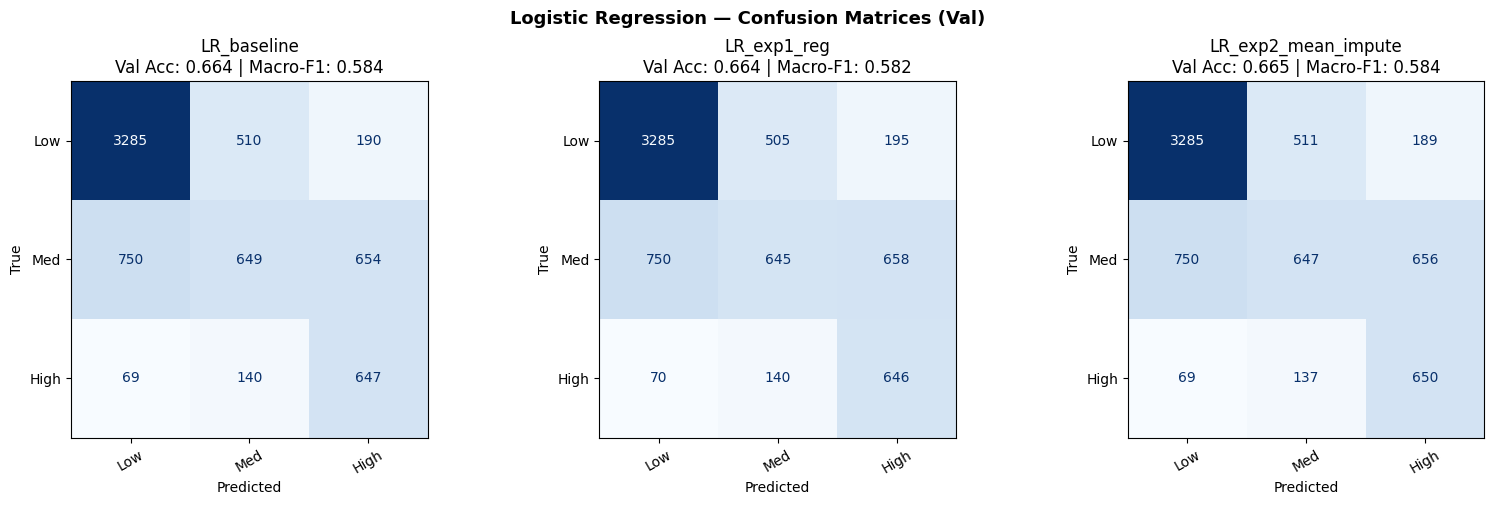

In [13]:
plot_confusion_matrices(lr_results, "Logistic Regression", X_val, y_val)

#### Logistic Regression Experiments: Interpretation
**Overall model accuracy 66%** is inflated by the dominant Class 0 showing 82% accuracy and class 2 75% accuracy. Class 1 has the lowest accuracy of 32%.


**Other Metrics:**

**Class 0** : Low : Precision : 0.80, Recall : 0.82, F1 : 0.81 Strongest class, the model has learned the majority class well. High support (3,985) helps.

**Class 1** : Medium : Precision : 0.50, Recall : 0.32, F1 : 0.39 This is the weakest class with low recall of 32%, meaning, the model misses most of the moderate bleaching events. It frequently misclassifies moderate bleaching as other classes which is an error for reef monitoring.

**Class 2** : High : Precision : 0.43, Recall : 0.76, F1 : 0.55 This class has high recall but low precision. The model over-predicts severe bleaching with 844 false positives.

Overall, the model is biased toward predicting extreme classes - Low and High while failing to accurately capture the intermediate class (Medium), which is a critical limitation for real-world reef monitoring applications.

**Experiments**: Logistic Regression Baseline experiments below progressively test: regularisation strength, and class imbalance handling. We ran two additional experiments to optimize the logistic regression baseline:

| Experiment | Configuration | Validation Acc | Key Finding |
|------------|---------------|----------------|--------------|
| **Exp 1** | Stronger regularization (C=0.1) | 66.0% | Slight performance drop, no improvement on Class 1 |
| **Exp 2** | Mean imputation | 66.3% | Marginal improvement, same class imbalance pattern |

### Results Summary

All three experiments yielded **similar performance** (66-67% validation accuracy) with identical failure patterns:

- **Class 0 (Low)**: Strong performance (82% accuracy, F1: 0.81)
- **Class 1 (Medium)**: **Critically weak** (32% recall, F1: 0.39) - model misses most moderate events
- **Class 2 (High)**: High recall (76%) but low precision (43%) - over-predicts severe bleaching


Despite tuning efforts (regularization, imputation strategies), logistic regression cannot overcome Non-linear relationships as bleaching severity likely has threshold effects with environmental variables. Feature interactions like temperature, duration, depth are multiplicative not additive which cannot be handled by logistic regression. Lastly linear models struggle with Class imbalance when decision boundaries are dominated by majority classes.

### Conclusion

**Logistic regression is insufficient for this coral bleaching classification problem.** The inability to improve Class 1 recall beyond 32% represents a fundamental limitation of linear models.

**We will now proceed to Random Forest**, which can:
- Capture non-linear patterns automatically
- Detect feature interactions without manual engineering
- Handle class imbalance more effectively through ensemble averaging
- Provide feature importance to identify key environmental drivers

The Random Forest model is expected to significantly improve moderate bleaching detection (Class 1 recall) while maintaining or improving overall accuracy.

#### Readings:
https://reefcloud.ai/

https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

https://medium.com/@shiwanigupta3005/feature-selection-techniques-for-classification-models-832ebfc6564d

https://pmc.ncbi.nlm.nih.gov/articles/PMC3347893/
<br>Efficient Feature Selection and Multiclass Classification with Integrated Instance and Model Based Learning: integrated KNN and constrained logistic regression (KNNLog) for simultaneous multiclass classification and feature selection. This method simultaneously minimizes the intra-class distance and maximizes the interclass distance with fewer estimated parameters. It is very efficient for problems with small sample size and unbalanced classes.

#### Model 2: Random Forest Classifier
Run with all 35 features
Experiment with argument values :
- n_estimators=10, 100, 200  : More trees for better average voting
- class weight = balanced
- n_jobs=-1  : It makes training faster by parallelizing across scores.
- random_state=42
- max_depth=8, 15, 20
- min_samples_split= 10,30,50  : Regularization to prevent overfitting
- min_samples_leaf - 5,15,25  : how many samples must be in a leaf node, Larger leaves prevent overfitting 
 - max_features = 'sqrt' or log2  : each split sees only sqrt(12288) i.e, about 110 randomly chosen features. log2 would give even fewer.

We can use grid search to find the best hyperparameters since our parameter space is small
Alternatively we use RandomizedSearch if we had a large parameter space

In [21]:
rf_experiments = {
    'RF_baseline': {
        'params': {'n_estimators': 50, 'class_weight': 'balanced', 'random_state': RANDOM_STATE, 
                   'min_samples_split' : 10, 'min_samples_leaf': 5, 'n_jobs': -1, 'max_depth':8},
        'description': 'RF baseline - 10 trees, depth=8'
    },
    'RF_exp1_depth': {
        'params': {'n_estimators': 100, 'max_depth': 15, 'class_weight': 'balanced', 
                   'min_samples_split' : 30,'min_samples_leaf': 15, 
                   'random_state': RANDOM_STATE, 'n_jobs': -1},
        'description': 'Depth-limited - 100 trees, max_depth=15'
    },
    'RF_exp2_features': {
        'params': {'criterion': 'entropy','n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 20,
                   'min_samples_split' : 50, 'min_samples_leaf': 25, 'class_weight': 'balanced_subsample', 
                   'random_state': RANDOM_STATE, 'n_jobs': -1},
        'description': 'sqrt features, balanced_subsample weights'
    },
}
# Experiment Loop
rf_results = {}
baseline_f1_rf = None # so that F1 is locked as the reference point and not overwritten

for exp_name, cfg in rf_experiments.items():
    print(f"\n{exp_name}: {cfg['params']}")

    # Build and fit pipeline
    pipe = build_pipeline(
        clf= RandomForestClassifier(**cfg['params']),
        numeric_strategy='median', # consistent imputation across experiments
        num_features=numeric_features,   # use ALL numeric features from pre-processing
        cat_features=categorical_features  # use ALL categorical features
    )
    pipe.fit(X_train, y_train)  # Use FULL feature set

    # Evaluate
    metrics = evaluate_model(
        pipe, X_train, y_train, X_val, y_val,
        baseline_f1_macro=baseline_f1_rf
    )

    # Store
    rf_results[exp_name] = {'metrics': metrics, 'model': pipe, 'config': cfg}

    if baseline_f1_rf is None:
        baseline_f1_rf = metrics['F1_macro']

# Store in master dict
ALL_RESULTS['RandomForest'] = rf_results

# --- Display summary table ---
rf_results_df = pd.DataFrame(
    {name: data['metrics'] for name, data in rf_results.items()}
).T.drop(columns=['Val_confusion_matrix'])

display(rf_results_df)


RF_baseline: {'n_estimators': 50, 'class_weight': 'balanced', 'random_state': 42, 'min_samples_split': 10, 'min_samples_leaf': 5, 'n_jobs': -1, 'max_depth': 8}

RF_exp1_depth: {'n_estimators': 100, 'max_depth': 15, 'class_weight': 'balanced', 'min_samples_split': 30, 'min_samples_leaf': 15, 'random_state': 42, 'n_jobs': -1}

RF_exp2_features: {'criterion': 'entropy', 'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 20, 'min_samples_split': 50, 'min_samples_leaf': 25, 'class_weight': 'balanced_subsample', 'random_state': 42, 'n_jobs': -1}


,Training_accuracy,Validation_accuracy,Gap,Precision_macro,Recall_macro,F1_macro,Weighted_F1,"Precision_per_class_[Low,Med,High]","Recall_per_class_[Low,Med,High]","F1_per_class_[Low,Med,High]",Support,Improvement_over_baseline_[F1_macro]
RF_baseline,0.779,0.757,0.022,0.7,0.735,0.698,0.744,"[0.829, 0.691, 0.58]","[0.897, 0.435, 0.874]","[0.862, 0.534, 0.697]","[3985, 2053, 856]",None
RF_exp1_depth,0.84,0.794,0.046,0.741,0.775,0.747,0.789,"[0.865, 0.742, 0.617]","[0.902, 0.556, 0.867]","[0.883, 0.636, 0.721]","[3985, 2053, 856]",0.049
RF_exp2_features,0.818,0.782,0.036,0.729,0.764,0.73,0.774,"[0.852, 0.738, 0.598]","[0.902, 0.506, 0.886]","[0.876, 0.6, 0.714]","[3985, 2053, 856]",0.032


RF_baseline
--------------------------------------------------
 Low bleaching accuracy: 0.897
 Med bleaching accuracy: 0.435
 High bleaching accuracy: 0.874

Classification Report:
              precision    recall  f1-score   support

         Low       0.83      0.90      0.86      3985
         Med       0.69      0.43      0.53      2053
        High       0.58      0.87      0.70       856

    accuracy                           0.76      6894
   macro avg       0.70      0.74      0.70      6894
weighted avg       0.76      0.76      0.74      6894

RF_exp1_depth
--------------------------------------------------
 Low bleaching accuracy: 0.902
 Med bleaching accuracy: 0.556
 High bleaching accuracy: 0.867

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.90      0.88      3985
         Med       0.74      0.56      0.64      2053
        High       0.62      0.87      0.72       856

    accuracy                         

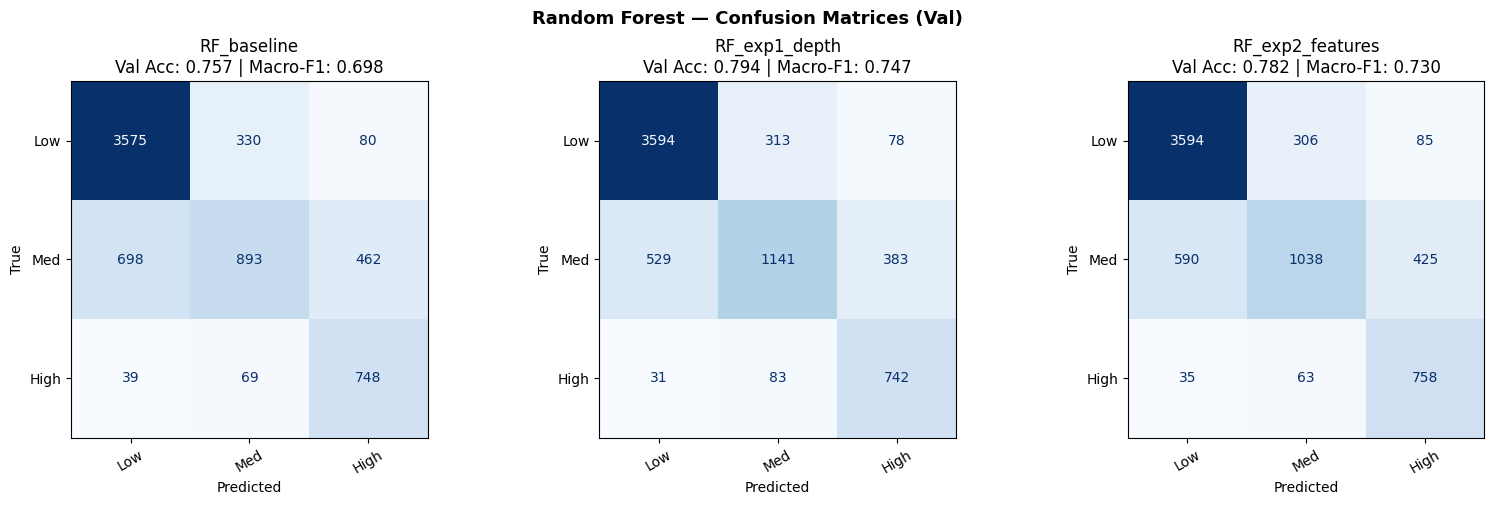

In [22]:
plot_confusion_matrices(rf_results, "Random Forest", X_val, y_val)

#### Random Forest Results Interpretation
The Random Forest classifier significantly outperformed Logistic Regression across all evaluation metrics, demonstrating its ability to capture complex non-linear relationships in the coral bleaching dataset. The baseline Random Forest model achieved a macro F1-score of 0.69, compared to 0.58 for Logistic Regression, indicating a substantial improvement in balanced class performance.

Among the experiments, RF_exp1_depth achieved the best performance with:
- Validation Accuracy: 0.794
- Macro F1-score: 0.747
- Improvement over baseline: +0.057

Increasing the number of trees and allowing deeper trees (max_depth=15) enables the model to better capture feature interactions while still maintaining generalization.

#### Class-wise Performance Insights
A consistent pattern across all Random Forest models is the variation in class-wise performance:
- Low bleaching class: High recall (0.90), indicating strong performance on majority class
- High bleaching class: Also well predicted (0.89 recall), likely due to clearer signal patterns
- Medium bleaching class: Significantly lower recall (0.51)

The model struggles to distinguish medium bleaching instances, often misclassifying them as either low or high bleaching. This behavior suggests that the medium class lies near decision boundaries and may not be well-separated in feature space.

RF feature importance

In [30]:
# FEATURE IMPORTANCE - RANDOM FOREST

def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    """
    Plot top N feature importances from a trained Random Forest model.
    Extracts the classifier from the pipeline.
    """
    # Extract the RandomForestClassifier from the pipeline
    if hasattr(model, 'named_steps'):
        rf_model = model.named_steps['clf']
    else:
        rf_model = model
    
    # Get feature names after preprocessing
    # This requires getting the transformed feature names from ColumnTransformer
    preprocessor = model.named_steps['preprocess']
    
    # Get feature names after one-hot encoding
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_features_encoded = cat_encoder.get_feature_names_out(categorical_features)
    
    # Combine numeric and encoded categorical feature names
    all_feature_names = list(numeric_features) + list(cat_features_encoded)
    
    # Get importances
    importances = rf_model.feature_importances_
    
    # Create DataFrame and sort
    feature_importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Plot top N
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(top_n)
    
    plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'{title} - Top {top_n} Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance_df

Identify best rf model and plot


Feature Importance for best model: RF_exp1_depth


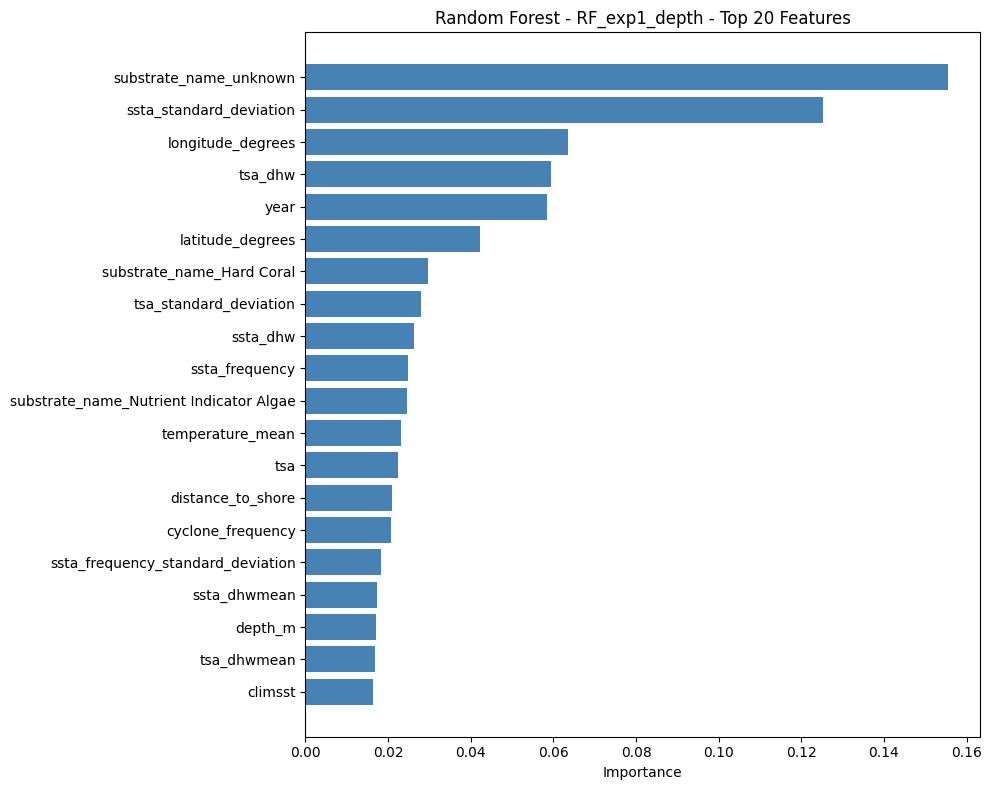


Top 10 Most Important Features:
                  feature  importance
   substrate_name_unknown    0.155442
  ssta_standard_deviation    0.125139
        longitude_degrees    0.063499
                  tsa_dhw    0.059438
                     year    0.058362
         latitude_degrees    0.042322
substrate_name_Hard Coral    0.029616
   tsa_standard_deviation    0.027997
                 ssta_dhw    0.026256
           ssta_frequency    0.024796


In [31]:
# Identify the best RF model
best_rf_exp = max(rf_results.items(), key=lambda x: x[1]['metrics']['F1_macro'])[0]
best_rf_model = rf_results[best_rf_exp]['model']
print(f"\nFeature Importance for best model: {best_rf_exp}")

# Plot for the best RF model (with highest macro-F1)
feature_importance_df = plot_feature_importance(
    best_rf_model, 
    numeric_features + categorical_features, 
    top_n=20,
    title=f"Random Forest - {best_rf_exp}"
)

# Display top 10 features
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))

Feature importance analysis reveals that both environmental variability and spatial factors play a key role in predicting coral bleaching. In particular, substrate type (unknown and hard coral) emerges as the most influential feature, suggesting that reef composition significantly impacts bleaching susceptibility.

Temperature-related variability metrics, such as SSTA standard deviation, TSA DHW, and SSTA frequency, are also among the top contributors, highlighting the importance of thermal stress and its fluctuations over time.

Additionally, geographical features (latitude and longitude) and temporal information (year) contribute meaningfully, indicating that bleaching patterns vary across both space and time.

#### Precision-Recall AUC Curve for the best model

In [ ]:
# PRECISION-RECALL CURVES WITH AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curves(model, X_val, y_val, model_name="Model", class_names=None):
    """
    Plot Precision-Recall curves for multi-class classification (one-vs-rest).
    """
    if class_names is None:
        class_names = ['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
    
    # Get predicted probabilities
    y_score = model.predict_proba(X_val)
    
    # Binarize the labels for one-vs-rest computation
    y_bin = label_binarize(y_val, classes=[0, 1, 2])
    
    # plot
    plt.figure(figsize=(8, 6))
    
    # Calculate PR curve and AUC for each class
    for i, class_name in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_bin[:, i], y_score[:, i])
        
        plt.plot(recall, precision, lw=2, label=f'{class_name} (AP = {ap:.3f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - Precision-Recall Curves')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.tight_layout()
    plt.show()

In [35]:
best_rf_exp

'RF_exp1_depth'

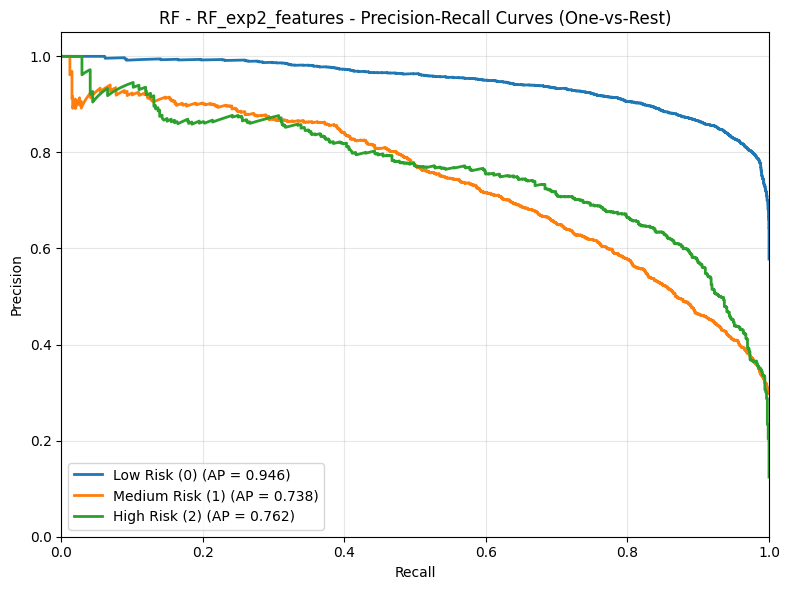

In [36]:
# Plot PR curves for all RF experiments
plot_pr_curves(
    best_rf_model, X_val, y_val, model_name=f"RF - {exp_name}",
    class_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
)

Precision-Recall (PR) curves provide further insight into model performance under class imbalance. The model achieves strong precision-recall trade-offs for the low and high bleaching classes, indicating confident and reliable predictions for these categories.

However, the PR curve for the medium bleaching class shows comparatively lower area and a weaker precision-recall trade-off. This suggests that the model struggles to balance precision and recall for this class, often misclassifying medium bleaching instances as either low or high.

This observation is consistent with the confusion matrix and class-wise metrics, reinforcing that the medium class remains the most challenging to predict.

Among all Random Forest experiments, RF_exp1_depth was selected as the best-performing model, achieving the highest macro F1-score (0.747) and validation accuracy (0.794). Increasing model capacity through deeper trees and more estimators improves performance on this dataset.

However, despite overall improvements, the model continues to underperform on the medium bleaching class, with relatively lower recall compared to the low and high classes. Random Forest struggles to model the more subtle decision boundaries associated with moderate bleaching conditions.

To address this limitation, we explore more advanced boosting-based models, such as HistGradientBoosting and XGBoost, which are known to better capture complex patterns and improve performance on harder-to-classify samples.

#### Hist Gradient Boosting:
- Uses histogram-based binning (faster on large datasets)
- Native NaN handling (no imputation needed)
- Uses 'max_iter' instead of 'n_estimators'
- Does NOT support 'subsample' — use 'max_bins' and 'max_leaf_nodes' instead

Argument Values: 
- max_iter = 100, 150, 300 : use more trees to compensate for lower learning rates
- learning_rate=0.1, 0.05  : balances speed vs. accuracy. Slower learning needs more trees
- n_estimators=100, 
- l2_regularization': 0.1, : reduces overfitting
- min_samples_split=10, 
- min_samples_leaf=20,30,40  : default is 20, large leaves = less overfitting. Regularization: prevents splits on tiny groups
- max_leaf_nodes : HGBT prefers this over max_depth alone. Fewer leaves matches shallow depth; avoids over-complex trees
- max_depth=5, : controls complexity per tree. Shallow trees prevent overfitting, high bias, low variance; Deeper trees capture complex interaction, ssafer for noisy data
- max_bins  : Max histogram bins; higher = finer splits, more memory 


In [43]:
# from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

hgbt_experiments = {
    'HGBT_baseline': {
        'params': {
            'loss': 'log_loss',
            'class_weight': 'balanced',
            'max_iter': 100,            
            'learning_rate': 0.1,       
            'max_depth': None,             
            'max_leaf_nodes': 31,       # Default (2^5-1)
            'min_samples_leaf': 20,     # Small leaf size  stronger regularization
            'l2_regularization': 0.0,   # no regularization on baseline
            'max_bins': 255, 
            'early_stopping': True,     # Stop early if val score plateaus           
            'random_state': RANDOM_STATE,
        },
        'description': 'Baseline — 100 iters, lr=0.1, depth=4, default bins'
    },
    'HGBT_exp1_regularized': {
        'params': {
            'loss': 'log_loss',
            'class_weight': 'balanced',
            'max_iter': 150,            # Fewer iters since deeper trees have more capacity
            'learning_rate': 0.05,      # Moderate lr; deeper trees risk overfitting with lr=0.1
            'max_depth': 6,             # Deeper trees capture complex interactions
            'max_leaf_nodes': 63,       # 2^6-1; consistent with depth=6
            'min_samples_leaf': 40,     # Larger min leaf to counteract depth's tendency to overfit
            'l2_regularization': 0.5,   # Stronger regularization to tame deep trees
            'max_bins': 255,            # Full bins
            'random_state': RANDOM_STATE,
        },
        'description': 'Deeper + regularized - depth=6, lr=0.05, strong L2, large min_leaf'
    },
    'HGBT_exp2_feature_sampling': {
        'params': {
            'loss': 'log_loss',
            'class_weight': 'balanced',
            'max_iter': 200,
            'learning_rate': 0.05,
            'max_depth': 4,             # Moderate depth
            'max_leaf_nodes': 31,       # Default (2^5-1)
            'min_samples_leaf': 30,
            'l2_regularization': 0.5,
            'max_features': 0.7,        # Use 70% of features per split
                                        # Reduces correlation between trees, better ensemble diversity
                                        # useful when there are many features
            'max_bins': 200,            # Slightly reduced bins for speed with feature sampling
            'random_state': RANDOM_STATE,
        },
        'description': 'Feature sampling — 70% features/split, depth=4, lr=0.05'
    }
}

In [44]:
# Experiment Loop
hg_results = {}
baseline_f1_hg = None # so that F1 is locked as the reference point and not overwritten

for exp_name, cfg in hgbt_experiments.items():
    print(f"\n{exp_name}: {cfg['params']}")

    # Build and fit pipeline
    pipe = build_pipeline(
        clf= HistGradientBoostingClassifier(**cfg['params']),
        numeric_strategy='median', # consistent imputation across experiments
        num_features=numeric_features,   # use ALL numeric features from pre-processing
        cat_features=categorical_features  # use ALL categorical features
    )
    pipe.fit(X_train, y_train)  # Use FULL feature set

    # Evaluate
    metrics = evaluate_model(
        pipe, X_train, y_train, X_val, y_val,
        baseline_f1_macro=baseline_f1_rf
    )

    # Store
    hg_results[exp_name] = {'metrics': metrics, 'model': pipe, 'config': cfg}

    if baseline_f1_hg is None:
        baseline_f1_hg = metrics['F1_macro']

# Store in master dict
ALL_RESULTS['RandomForest'] = rf_results

# --- Display summary table ---
hg_results_df = pd.DataFrame(
    {name: data['metrics'] for name, data in hg_results.items()}
).T.drop(columns=['Val_confusion_matrix'])

display(hg_results_df)


HGBT_baseline: {'loss': 'log_loss', 'class_weight': 'balanced', 'max_iter': 100, 'learning_rate': 0.1, 'max_depth': None, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'max_bins': 255, 'early_stopping': True, 'random_state': 42}

HGBT_exp1_regularized: {'loss': 'log_loss', 'class_weight': 'balanced', 'max_iter': 150, 'learning_rate': 0.05, 'max_depth': 6, 'max_leaf_nodes': 63, 'min_samples_leaf': 40, 'l2_regularization': 0.5, 'max_bins': 255, 'random_state': 42}

HGBT_exp2_feature_sampling: {'loss': 'log_loss', 'class_weight': 'balanced', 'max_iter': 200, 'learning_rate': 0.05, 'max_depth': 4, 'max_leaf_nodes': 31, 'min_samples_leaf': 30, 'l2_regularization': 0.5, 'max_features': 0.7, 'max_bins': 200, 'random_state': 42}


,Training_accuracy,Validation_accuracy,Gap,Precision_macro,Recall_macro,F1_macro,Weighted_F1,"Precision_per_class_[Low,Med,High]","Recall_per_class_[Low,Med,High]","F1_per_class_[Low,Med,High]",Support,Improvement_over_baseline_[F1_macro]
HGBT_baseline,0.904,0.831,0.073,0.781,0.814,0.793,0.831,"[0.906, 0.759, 0.678]","[0.907, 0.671, 0.862]","[0.907, 0.713, 0.759]","[3985, 2053, 856]",0.095
HGBT_exp1_regularized,0.868,0.813,0.055,0.762,0.798,0.773,0.81,"[0.887, 0.742, 0.656]","[0.899, 0.618, 0.877]","[0.893, 0.674, 0.751]","[3985, 2053, 856]",0.075
HGBT_exp2_feature_sampling,0.818,0.786,0.033,0.731,0.773,0.742,0.782,"[0.867, 0.703, 0.623]","[0.884, 0.557, 0.877]","[0.875, 0.622, 0.728]","[3985, 2053, 856]",0.044


#### Model 4: XGBoost


Running: XGB_baseline - Baseline – 100 trees, lr=0.1, depth=4
✓ Completed in 1.4s
                  precision    recall  f1-score   support

   Low Bleaching       0.82      0.96      0.88      3985
Medium Bleaching       0.73      0.51      0.60      2053
  High Bleaching       0.72      0.66      0.69       856

        accuracy                           0.79      6894
       macro avg       0.76      0.71      0.72      6894
    weighted avg       0.78      0.79      0.77      6894


Running: XGB_exp1_scale - Slower learning – 200 trees, lr=0.05
✓ Completed in 2.1s
                  precision    recall  f1-score   support

   Low Bleaching       0.81      0.96      0.88      3985
Medium Bleaching       0.73      0.51      0.60      2053
  High Bleaching       0.73      0.66      0.69       856

        accuracy                           0.79      6894
       macro avg       0.76      0.71      0.72      6894
    weighted avg       0.78      0.79      0.77      6894


Running: XGB_e

,Experiment,Description,Train Acc,Val Acc,Val Macro-F1,Val Weighted-F1,Gap (Train-Val),Time (s)
0,XGB_baseline,"Baseline – 100 trees, lr=0.1, depth=4",0.8053,0.7874,0.7240,0.7738,0.0180,1.4
1,XGB_exp1_scale,"Slower learning – 200 trees, lr=0.05",0.8050,0.7869,0.7238,0.7733,0.0181,2.1
2,XGB_exp2_reg,"L1+L2 regularization, depth=5",0.8363,0.8061,0.7526,0.7952,0.0303,2.7


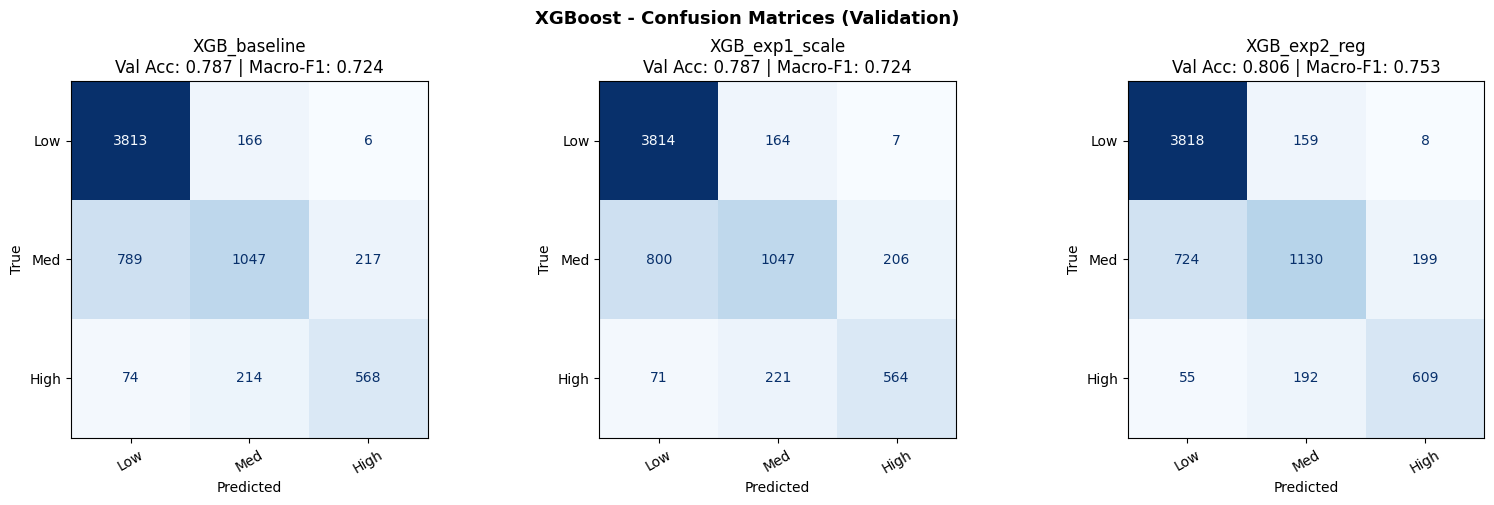

In [22]:
# XGBoost needs numeric labels 0,1,2
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode target labels (0,1,2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)   # keep for later final evaluation

xgb_experiments = {
    'XGB_baseline': {
        'params': {
            'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4,
            'subsample': 0.8, 'colsample_bytree': 0.8,
            'use_label_encoder': False, 'eval_metric': 'mlogloss',
            'random_state': RANDOM_STATE, 'n_jobs': -1
        },
        'description': 'Baseline – 100 trees, lr=0.1, depth=4'
    },
    'XGB_exp1_scale': {
        'params': {
            'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4,
            'subsample': 0.8, 'colsample_bytree': 0.8,
            'use_label_encoder': False, 'eval_metric': 'mlogloss',
            'random_state': RANDOM_STATE, 'n_jobs': -1
        },
        'description': 'Slower learning – 200 trees, lr=0.05'
    },
    'XGB_exp2_reg': {
        'params': {
            'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5,
            'subsample': 0.7, 'colsample_bytree': 0.7,
            'reg_alpha': 0.1, 'reg_lambda': 1.5,
            'use_label_encoder': False, 'eval_metric': 'mlogloss',
            'random_state': RANDOM_STATE, 'n_jobs': -1
        },
        'description': 'L1+L2 regularization, depth=5'
    },
}

xgb_rows = []
xgb_results = {}

for exp_name, cfg in xgb_experiments.items():
    print(f"\n{'='*60}\nRunning: {exp_name} - {cfg['description']}")
    t0 = time.time()

    preprocessor = build_preprocessor('median')
    pipe = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(**cfg['params']))])
    pipe.fit(X_train, y_train_enc)          # fit on encoded labels

    train_metrics = evaluate_model(pipe, X_train, y_train_enc, 'Train')
    val_metrics   = evaluate_model(pipe, X_val,   y_val_enc,   'Val')
    gap = train_metrics['Train_accuracy'] - val_metrics['Val_accuracy']
    elapsed = time.time() - t0

    xgb_results[exp_name] = {
        'model': pipe,
        'config': cfg,
        'metrics': {**train_metrics, **val_metrics},
        'gap': gap
    }

    xgb_rows.append({
        'Experiment': exp_name,
        'Description': cfg['description'],
        'Train Acc': round(train_metrics['Train_accuracy'], 4),
        'Val Acc': round(val_metrics['Val_accuracy'], 4),
        'Val Macro-F1': round(val_metrics['Val_macro_f1'], 4),
        'Val Weighted-F1': round(val_metrics['Val_weighted_f1'], 4),
        'Gap (Train-Val)': round(gap, 4),
        'Time (s)': round(elapsed, 1)
    })

    print(f"✓ Completed in {elapsed:.1f}s")
    # classification report expects original labels. Use encoded but with target_names
    print(classification_report(y_val_enc, pipe.predict(X_val), target_names=TARGET_NAMES))

xgb_df = pd.DataFrame(xgb_rows)
print("\n" + "="*80)
print("XGBOOST EXPERIMENTS - SUMMARY")
print("="*80)
display(xgb_df)

ALL_RESULTS['XGBoost'] = xgb_results
plot_confusion_matrices(xgb_results, 'XGBoost')

2026-04-12 15:48:05.395733: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,427 (60.26 KB)

 Trainable params: 15,427 (60.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6804 - loss: 0.8699 - val_accuracy: 0.7435 - val_loss: 0.7368
Epoch 2/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7256 - loss: 0.7528 - val_accuracy: 0.7462 - val_loss: 0.6872
Epoch 3/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7309 - loss: 0.7102 - val_accuracy: 0.7517 - val_loss: 0.6600
Epoch 4/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7379 - loss: 0.6785 - val_accuracy: 0.7473 - val_loss: 0.6406
Epoch 5/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7417 - loss: 0.6612 - val_accuracy: 0.7627 - val_loss: 0.6231
Epoch 6/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7447 - loss: 0.6456 - val_accuracy: 0.7528 - val_loss: 0.6125
Epoch 7/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7478 - loss: 0.6331 - val_accuracy: 0.7623 - val_loss: 0.6019
Epoch 8/100
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7479 - loss: 0.6229 - val_accu

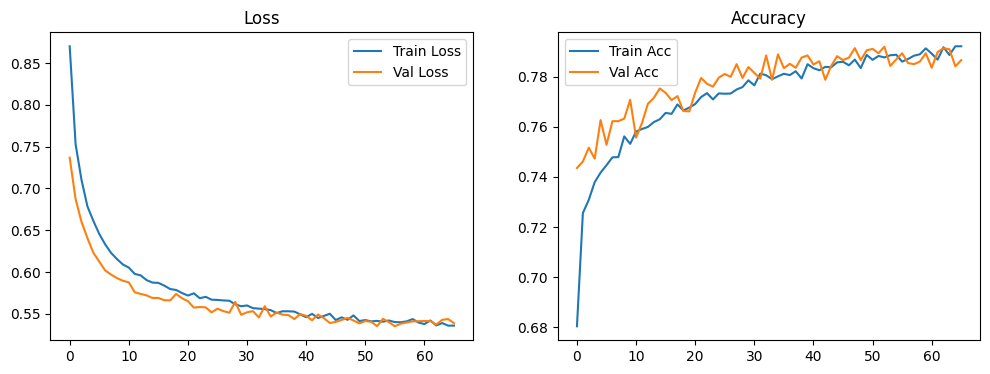

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Use the same preprocessor as RF (fit on training data only)
preprocessor = build_preprocessor('median')
preprocessor.fit(X_train)

# Transform data to dense arrays
X_train_tf = preprocessor.transform(X_train).astype(np.float32)
X_val_tf   = preprocessor.transform(X_val).astype(np.float32)

# One-hot encode target (3 classes)
y_train_oh = keras.utils.to_categorical(y_train, num_classes=3)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes=3)

# Build a simple MLP
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_nn(X_train_tf.shape[1])
model.summary()

# Early stopping to avoid overfitting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(
    X_train_tf, y_train_oh,
    validation_data=(X_val_tf, y_val_oh),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on validation
y_val_pred_prob = model.predict(X_val_tf)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

print("\nNeural Network Validation Performance")
print("="*50)
print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=TARGET_NAMES))

# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')
plt.show()

#### Ablation Study

In [23]:
# Collect all rows from each model's DataFrame
all_ablation_rows = []
for model_name, results_dict in ALL_RESULTS.items():
    for exp_name, exp_data in results_dict.items():
        m = exp_data['metrics']
        all_ablation_rows.append({
            'Model': model_name,
            'Experiment': exp_name,
            'Description': exp_data['config']['description'],
            'Train Acc': round(m['Train_accuracy'], 4),
            'Val Acc': round(m['Val_accuracy'], 4),
            'Val Macro-F1': round(m['Val_macro_f1'], 4),
            'Val Weighted-F1': round(m['Val_weighted_f1'], 4),
            'Gap': round(exp_data['gap'], 4)
        })

ablation_df = pd.DataFrame(all_ablation_rows)
ablation_df = ablation_df.sort_values('Val Macro-F1', ascending=False)

print("\n" + "="*80)
print("MASTER ABLATION TABLE – ALL MODELS & EXPERIMENTS")
print("="*80)
display(ablation_df)

# Optional: save to CSV
ablation_df.to_csv('artifacts/ablation_results.csv', index=False)


MASTER ABLATION TABLE – ALL MODELS & EXPERIMENTS


,Model,Experiment,Description,Train Acc,Val Acc,Val Macro-F1,Val Weighted-F1,Gap
5,RandomForest,RF_exp2_features,"sqrt features, balanced_subsample weights",0.9926,0.8484,0.8020,0.8455,0.1442
8,GradientBoosting,GBT_exp2_deeper,Deeper + feature sampling – depth=6,0.9004,0.8320,0.7837,0.8257,0.0684
4,RandomForest,RF_exp1_depth,"Depth-limited - 200 trees, max_depth=15",0.9079,0.8271,0.7814,0.8230,0.0808
11,XGBoost,XGB_exp2_reg,"L1+L2 regularization, depth=5",0.8363,0.8061,0.7526,0.7952,0.0303
6,GradientBoosting,GBT_baseline,"Baseline – 100 trees, lr=0.1, depth=4",0.8245,0.7992,0.7410,0.7884,0.0252
9,XGBoost,XGB_baseline,"Baseline – 100 trees, lr=0.1, depth=4",0.8053,0.7874,0.7240,0.7738,0.0180
10,XGBoost,XGB_exp1_scale,"Slower learning – 200 trees, lr=0.05",0.8050,0.7869,0.7238,0.7733,0.0181
7,GradientBoosting,GBT_exp1_shallow,"Shallow + slower – 200 trees, lr=0.05, depth=3",0.7869,0.7768,0.7067,0.7627,0.0102
3,RandomForest,RF_baseline,"RF baseline - 10 trees, depth=8",0.7792,0.7520,0.6870,0.7374,0.0272
2,LogisticRegression,LR_exp2_mean_impute,"Mean imputation, C=1.0",0.6601,0.6646,0.5839,0.6532,-0.0045


#### Final Evaluation - on Test Set with best chosen model

FINAL TEST SET RESULTS (RF_exp2_features)
Test Accuracy  : 0.8557
Macro F1       : 0.8155
Weighted F1    : 0.8532

Classification Report:
                  precision    recall  f1-score   support

   Low Bleaching       0.90      0.94      0.92      3986
Medium Bleaching       0.80      0.71      0.76      2053
  High Bleaching       0.76      0.78      0.77       855

        accuracy                           0.86      6894
       macro avg       0.82      0.81      0.82      6894
    weighted avg       0.85      0.86      0.85      6894



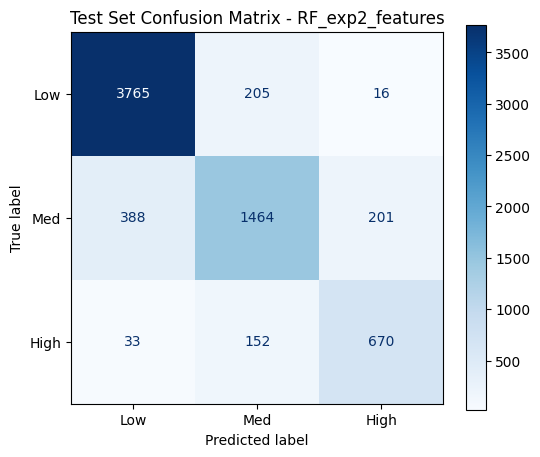


Final model saved to artifacts/final_model_rf_exp2_features.pkl


In [25]:
# Select the best model
best_model = ALL_RESULTS['RandomForest']['RF_exp2_features']['model']

# Predict on test set
y_test_pred = best_model.predict(X_test)

# Metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("FINAL TEST SET RESULTS (RF_exp2_features)")
print("="*50)
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Macro F1       : {test_macro_f1:.4f}")
print(f"Weighted F1    : {test_weighted_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=TARGET_NAMES))

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, 
                                        display_labels=['Low','Med','High'],
                                        cmap='Blues', ax=ax)
ax.set_title('Test Set Confusion Matrix - RF_exp2_features')
plt.show()

# Save the final model
joblib.dump(best_model, 'artifacts/final_model_rf_exp2_features.pkl')
print("\nFinal model saved to artifacts/final_model_rf_exp2_features.pkl")